# Customer Transaction & Behavior Analysis
**DSA1080A – Programming for Data Science | Spring Semester 2026 | USIU-Africa**

**Student:** Gad Rubuye | **Student ID:** 677569


## Section 1 — Setup & Imports

In [46]:
# Importing all libraries required across the full project.
# Grouped by purpose for clarity and maintainability.

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings — ensures plots render inline in Jupyter
%matplotlib inline

# Setting a clean, consistent visual style for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suppressing non-critical warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 2 — Data Loading & First Inspection

In [47]:
# Loading the raw dataset using ISO-8859-1 encoding.
# This encoding is required because the file contains special characters
# (e.g. accented letters in product descriptions) that UTF-8 cannot parse.
# Without specifying this, pandas raises a UnicodeDecodeError.

df = pd.read_csv('/Users/mac/Desktop/DSA1080/Final Project/data/raw_dataset.csv', encoding='ISO-8859-1')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 541,909 rows × 8 columns


In [48]:
# Inspecting column names, data types, and non-null counts.
# This gives us a complete structural overview before any cleaning begins.
# Key things to look for: object types that should be dates or numbers,
# and columns with fewer non-null entries than the total row count.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [49]:
# Generating descriptive statistics for all numeric columns.
# We use the median alongside the mean to detect skewness early.
# If mean >> median, the distribution is right-skewed — common in revenue data
# where a small number of high-value transactions pull the average upward.

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [50]:
# Previewing the first 5 rows to verify structure and content.
# This confirms column values match expected formats before we begin cleaning.

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
## Section 3 — Data Cleaning

### 3.1 — Missing Value Analysis

In [51]:
# Calculating missing value count and percentage for every column.
# Percentage is more meaningful than count alone — it tells us
# whether missing data is isolated noise or a structural problem.

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})

# Only showing columns that actually have missing values
print(missing_summary[missing_summary['Missing Count'] > 0])

             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


In [52]:
# Dropping rows where CustomerID is missing.
# CustomerID is the backbone of all customer-level analysis in this project —
# purchase frequency, revenue per customer, and repeat vs new customer logic
# all require a valid customer identifier. Rows without it cannot contribute
# to any of our four focus areas and must be removed.
# This affects ~24.9% of rows — a significant but justified removal.

df.dropna(subset=['CustomerID'], inplace=True)

print(f'Rows after dropping missing CustomerID: {len(df):,}')

Rows after dropping missing CustomerID: 406,829


In [53]:
# Dropping rows where Description is missing.
# Product descriptions are used in top-selling product analysis.
# Without a description, a product cannot be named or ranked meaningfully.
# Given that only 1,454 rows are affected (<0.3%), this is a safe removal
# with no material impact on dataset size or analysis quality.

df.dropna(subset=['Description'], inplace=True)

print(f'Rows after dropping missing Description: {len(df):,}')

Rows after dropping missing Description: 406,829


### 3.2 — Duplicate Removal

In [54]:
# Checking for fully duplicate rows — where every column value is identical.
# Duplicates in transaction data typically arise from system errors or
# double-logging events, and would artificially inflate revenue and frequency.

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count:,}')

Duplicate rows found: 5,225


In [55]:
# Removing duplicate rows, keeping the first occurrence.
# The first occurrence is retained as it represents the original transaction record.

df.drop_duplicates(inplace=True)

print(f'Rows after duplicate removal: {len(df):,}')

Rows after duplicate removal: 401,604


### 3.3 — Data Type Corrections

In [56]:
# Converting InvoiceDate from string (object) to datetime.
# This is essential for all time-based analysis in Week 3 —
# monthly revenue trends, peak purchasing periods, and seasonal patterns
# all require datetime operations that are impossible on string values.

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'InvoiceDate dtype after conversion: {df["InvoiceDate"].dtype}')
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')

InvoiceDate dtype after conversion: datetime64[ns]
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [57]:
# Converting CustomerID from float64 to string.
# CustomerID was loaded as a float because of NaN values (which pandas
# represents as float). Now that NaNs are removed, we convert to string
# to prevent accidental arithmetic on what is purely an identifier.
# We also strip the decimal point (e.g. 17850.0 → '17850') for clean display.

df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

print(f'CustomerID dtype after conversion: {df["CustomerID"].dtype}')
print(f'Sample CustomerIDs: {df["CustomerID"].head(3).tolist()}')

CustomerID dtype after conversion: object
Sample CustomerIDs: ['17850', '17850', '17850']


### 3.4 — Removing Cancellations & Invalid Transactions

In [58]:
# Removing cancelled transactions — identified by InvoiceNo starting with 'C'.
# Cancellations represent reversed purchases and must be excluded because:
# 1. They would reduce revenue totals below actual earned revenue
# 2. They would distort purchase frequency counts per customer
# 3. They do not represent genuine customer purchasing behavior

cancelled_mask = df['InvoiceNo'].astype(str).str.startswith('C')
print(f'Cancelled transactions found: {cancelled_mask.sum():,}')

df = df[~cancelled_mask]
print(f'Rows after removing cancellations: {len(df):,}')

Cancelled transactions found: 8,872
Rows after removing cancellations: 392,732


In [59]:
# Removing rows where Quantity or UnitPrice is zero or negative.
# Using IQR logic to contextualize this decision:
# Negative quantities represent returns or data entry errors.
# Zero-price items represent samples or gifts — not revenue-generating transactions.
# Both categories would corrupt revenue calculations and spending distribution analysis.

before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
after = len(df)

print(f'Rows removed due to invalid Quantity/UnitPrice: {before - after:,}')
print(f'Rows remaining: {after:,}')

Rows removed due to invalid Quantity/UnitPrice: 40
Rows remaining: 392,692


### 3.5 — Deriving the Revenue Column

In [60]:
# Creating a Revenue column as Quantity × UnitPrice.
# Revenue is our primary financial metric and does not exist as a raw column —
# it must be derived. This single column underpins:
# - Revenue per customer analysis
# - Top-selling product rankings
# - Country-level revenue comparison
# - Spending distribution analysis

df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Revenue column created.')
print(f'Total revenue in dataset: £{df["Revenue"].sum():,.2f}')
print(f'Average revenue per transaction: £{df["Revenue"].mean():,.2f}')
print(f'Median revenue per transaction: £{df["Revenue"].median():,.2f}')

Revenue column created.
Total revenue in dataset: £8,887,208.89
Average revenue per transaction: £22.63
Median revenue per transaction: £12.45


### 3.6 — Adding Useful Date Columns

In [61]:
# Extracting Month, Day of Week, and Hour from InvoiceDate.
# These derived columns avoid repeated datetime parsing in later sections
# and directly enable time-based visualizations in Week 3:
# - Month → monthly revenue trend line chart
# - DayOfWeek + Hour → purchase activity heatmap

df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print('Date columns extracted: Month, DayOfWeek, Hour')
print(f'Sample months: {df["Month"].unique()[:5].tolist()}')

Date columns extracted: Month, DayOfWeek, Hour
Sample months: ['2010-12', '2011-01', '2011-02', '2011-03', '2011-04']


### 3.7 — Features Engineering 

In [62]:

# All columns below are derived exclusively from existing data.

# ── DATE FEATURES ────────────────────────────────────────────────────────────
df['Year']        = df['InvoiceDate'].dt.year
df['Quarter']     = df['InvoiceDate'].dt.quarter
df['MonthNum']    = df['InvoiceDate'].dt.month
df['WeekOfYear']  = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfMonth']  = df['InvoiceDate'].dt.day

# ── REVENUE / FINANCIAL FEATURES ─────────────────────────────────────────────
df['RevenuePerUnit']    = df['Revenue'] / df['Quantity']
df['PriceCategory']     = pd.cut(df['UnitPrice'],
                                  bins=[0, 1, 5, 20, df['UnitPrice'].max()],
                                  labels=['Low', 'Mid', 'High', 'Premium'])
df['QuantityCategory']  = pd.cut(df['Quantity'],
                                  bins=[0, 5, 20, 100, df['Quantity'].max()],
                                  labels=['Small', 'Medium', 'Large', 'Bulk'])
df['IsHighValue']       = df['Revenue'] > df['Revenue'].median()

# ── CUSTOMER-LEVEL FEATURES ───────────────────────────────────────────────────
customer_stats = df.groupby('CustomerID').agg(
    CustomerOrderCount    = ('InvoiceNo', 'nunique'),
    CustomerTotalRevenue  = ('Revenue', 'sum'),
    CustomerAvgOrderValue = ('Revenue', 'mean'),
    CustomerCountry       = ('Country', 'first')
).reset_index()

df = df.merge(customer_stats, on='CustomerID', how='left')

# ── PRODUCT-LEVEL FEATURES ────────────────────────────────────────────────────
product_stats = df.groupby('StockCode').agg(
    ProductTotalRevenue       = ('Revenue', 'sum'),
    ProductTotalQuantitySold  = ('Quantity', 'sum'),
    ProductOrderCount         = ('InvoiceNo', 'nunique')
).reset_index()

df = df.merge(product_stats, on='StockCode', how='left')

df['DescriptionLength'] = df['Description'].str.len()

# ── COUNTRY-LEVEL FEATURES ────────────────────────────────────────────────────
country_stats = df.groupby('Country').agg(
    CountryTotalRevenue = ('Revenue', 'sum')
).reset_index()

df = df.merge(country_stats, on='Country', how='left')
df['IsUK'] = df['Country'] == 'United Kingdom'

# ── INVOICE-LEVEL FEATURES ────────────────────────────────────────────────────
invoice_stats = df.groupby('InvoiceNo').agg(
    InvoiceItemCount    = ('StockCode', 'nunique'),
    InvoiceTotalRevenue = ('Revenue', 'sum'),
    InvoiceTotalQuantity = ('Quantity', 'sum')
).reset_index()

df = df.merge(invoice_stats, on='InvoiceNo', how='left')

# ── FINAL COLUMN COUNT ────────────────────────────────────────────────────────
print(f'Total columns after feature engineering: {df.shape[1]}')
print(f'Total rows: {df.shape[0]:,}')
print(f'\nAll columns:\n{df.columns.tolist()}')

Total columns after feature engineering: 34
Total rows: 392,692

All columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month', 'DayOfWeek', 'Hour', 'Year', 'Quarter', 'MonthNum', 'WeekOfYear', 'DayOfMonth', 'RevenuePerUnit', 'PriceCategory', 'QuantityCategory', 'IsHighValue', 'CustomerOrderCount', 'CustomerTotalRevenue', 'CustomerAvgOrderValue', 'CustomerCountry', 'ProductTotalRevenue', 'ProductTotalQuantitySold', 'ProductOrderCount', 'DescriptionLength', 'CountryTotalRevenue', 'IsUK', 'InvoiceItemCount', 'InvoiceTotalRevenue', 'InvoiceTotalQuantity']


### 3.8 — Final Dataset Summary

In [63]:
# Final inspection of the cleaned dataset before saving.
# Confirming: no missing values remain, all data types are correct,
# and the row count reflects all cleaning decisions made above.

print('=== CLEANED DATASET SUMMARY ===')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nMissing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else 'None — dataset is fully clean.')
print(f'\nData types:')
print(df.dtypes)
print(f'\nColumns: {df.columns.tolist()}')

=== CLEANED DATASET SUMMARY ===
Final shape: 392,692 rows × 34 columns

Missing values remaining:
None — dataset is fully clean.

Data types:
InvoiceNo                           object
StockCode                           object
Description                         object
Quantity                             int64
InvoiceDate                 datetime64[ns]
UnitPrice                          float64
CustomerID                          object
Country                             object
Revenue                            float64
Month                               object
DayOfWeek                           object
Hour                                 int32
Year                                 int32
Quarter                              int32
MonthNum                             int32
WeekOfYear                           int64
DayOfMonth                           int32
RevenuePerUnit                     float64
PriceCategory                     category
QuantityCategory                  categor

### 3.9 — Saving the Cleaned Dataset

In [64]:
# Saving the cleaned dataset to the /data folder.
# index=False prevents pandas from writing the row index as an extra column,
# which would create an unnamed column that serves no analytical purpose.
# This file will be the single source of truth for all analysis in Weeks 3 and 4.

df.to_csv('/Users/mac/Desktop/DSA1080/Final Project/data/cleaned_dataset.csv', index=False)

print(f'Cleaned dataset saved to data/cleaned_dataset.csv')
print(f'Final row count: {len(df):,}')

Cleaned dataset saved to data/cleaned_dataset.csv
Final row count: 392,692


---
## Section 4 — Exploratory Data Analysis

### 4.1 — Summary Statistics

In [65]:
# Summary statistics for key numeric columns.
# Comparing mean vs median reveals distribution shape —
# a mean significantly higher than the median confirms right skew,
# which is expected in retail revenue and quantity data.

df[['Quantity', 'UnitPrice', 'Revenue', 'CustomerTotalRevenue', 'CustomerOrderCount']].describe().round(2)


,Quantity,UnitPrice,Revenue,CustomerTotalRevenue,CustomerOrderCount
count,392692.00,392692.00,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63,11565.75,18.79
std,180.49,22.24,311.10,31431.82,37.29
min,1.00,0.00,0.00,3.75,1.00
25%,2.00,1.25,4.95,1097.62,3.00
50%,6.00,1.95,12.45,2662.06,7.00
75%,12.00,3.75,19.80,6287.77,15.00
max,80995.00,8142.75,168469.60,280206.02,209.00


#### 4.1.a. — Interpretation
Revenue and quantity distributions are strongly right-skewed across all financial columns. The mean revenue per transaction (£22.63) sits well above the median (£12.45), confirming that a small number of high-value transactions pull the average upward. Customer total revenue shows an even more extreme divergence with a mean of £11,565 against a median of £2,662 which is indicating that a small segment of high-value customers drives a disproportionate share of total revenue. In skewed distributions, the median is the more representative measure of typical behavior.

### 4.2 — Grouping & Aggregation

In [66]:
# Aggregating revenue by country, product, month, and customer.
# These groupings are the foundation for all visualizations below
# and avoid repeating the same groupby logic in every chart cell.

country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index().sort_values('Month')
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

print('Aggregations complete.')
print(f'Countries: {len(country_revenue)}')
print(f'Unique products: {len(product_revenue)}')
print(f'Months in dataset: {len(monthly_revenue)}')
print(f'Unique customers: {len(customer_revenue)}')

Aggregations complete.
Countries: 37
Unique products: 3877
Months in dataset: 13
Unique customers: 4338


### 4.3 — Bar Chart: Top 10 Products by Revenue

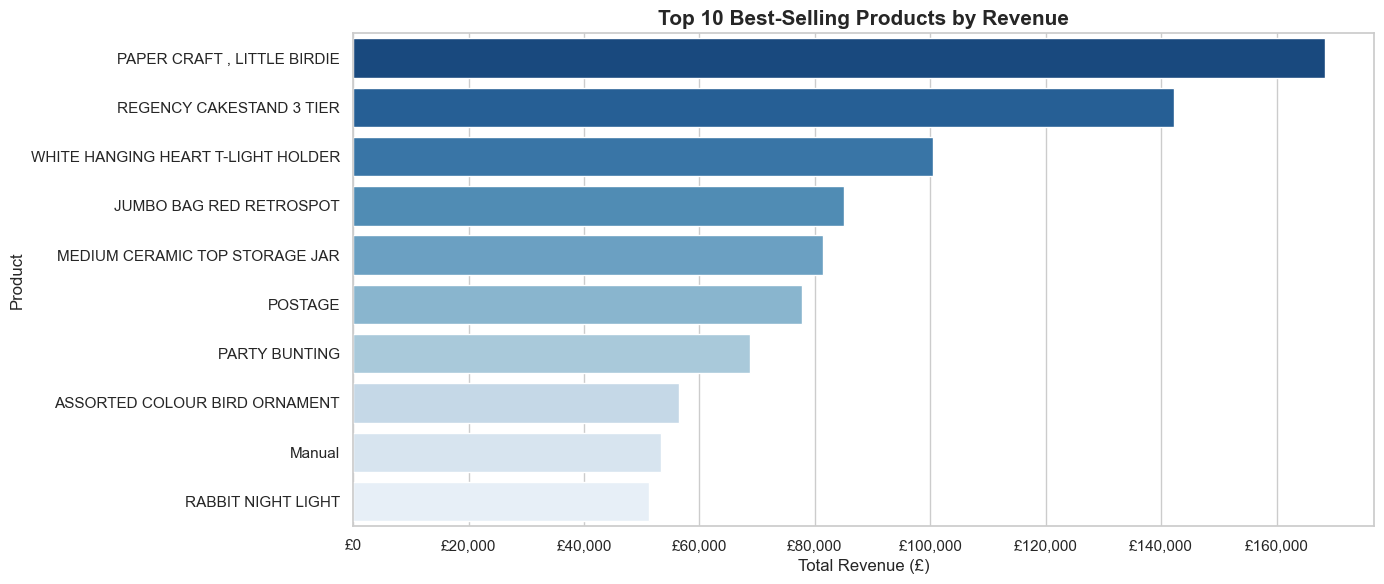

In [67]:
fig, ax = plt.subplots(figsize=(14, 6))

top_products = product_revenue.head(10)

sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r', ax=ax)

ax.set_title('Top 10 Best-Selling Products by Revenue', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/top10_products_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.a. — Interpretation
Revenue is concentrated among a small set of home décor, kitchenware, and gift products. Consistent with the retailer's wholesale catalogue profile. PAPER CRAFT, LITTLE BIRDIE leads all products at approximately £165,000, followed closely by REGENCY CAKESTAND 3 TIER at £140,000 and WHITE HANGING HEART T-LIGHT HOLDER at £100,000. Notably, POSTAGE and Manual appear in the top 10. These are non-product entries that inflate the ranking and should be excluded from product-level recommendations. The steep revenue drop-off from the third to the tenth product confirms that a core set of three to four items drives the majority of product revenue, warranting prioritized inventory management and targeted promotional support for these lines.

### 4.4. —  Line Chart: Monthly Revenue Trend

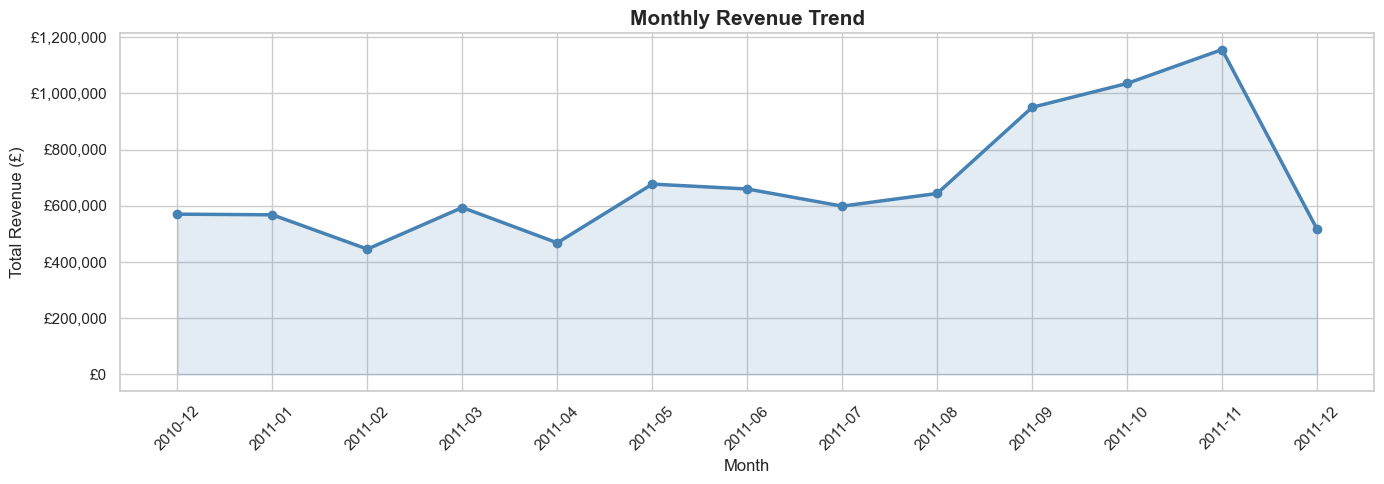

In [68]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_revenue['Month'], monthly_revenue['Revenue'],
        marker='o', linewidth=2.5, color='steelblue', markersize=6)

ax.fill_between(monthly_revenue['Month'], monthly_revenue['Revenue'],
                alpha=0.15, color='steelblue')

ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4.a — Interpretation
Revenue follows a clear seasonal pattern with a strong acceleration in Q4. The first half of the year maintains relatively stable revenue between £450,000 and £680,000, with February and April representing the two weakest months at £446,085 and £468,374 respectively. From September onwards, revenue accelerates sharply by rising from £950,690 in September to a peak of £1,156,206 in November, driven by pre-holiday wholesale purchasing. December drops to £517,190, which reflects incomplete data for that month rather than an actual revenue decline. This seasonal concentration in Q4 has direct implications for inventory planning, staffing, and promotional timing.

### 4.5 — Distribution Plot: Customer Spending

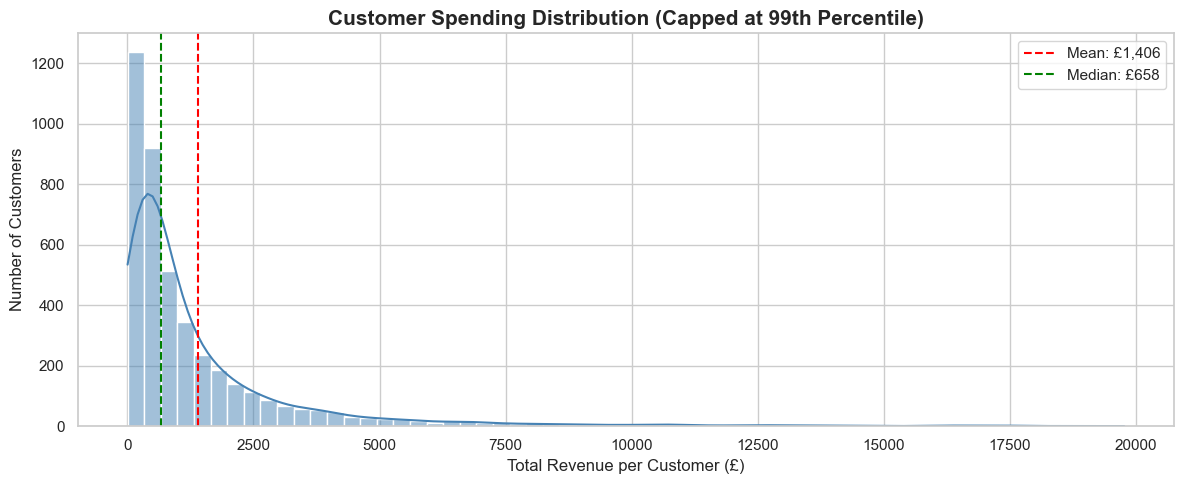

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))

# Capping at 99th percentile to prevent extreme outliers from
# compressing the distribution and obscuring the typical spending pattern
cap = customer_revenue.quantile(0.99)
spending_capped = customer_revenue[customer_revenue <= cap]

sns.histplot(spending_capped, bins=60, kde=True, color='steelblue', ax=ax)

ax.axvline(spending_capped.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean: £{spending_capped.mean():,.0f}')
ax.axvline(spending_capped.median(), color='green', linestyle='--',
           linewidth=1.5, label=f'Median: £{spending_capped.median():,.0f}')

ax.set_title('Customer Spending Distribution (Capped at 99th Percentile)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue per Customer (£)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/customer_spending_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.5.a. — Interpretation
Customer spending is strongly right-skewed, as confirmed by the significant gap between the median (£658) and the mean (£1,406) within the 99th percentile cap. The majority of customers (over 1,200) cluster in the lowest spending bracket below £500, while the distribution tapers off sharply toward higher spending levels. The mean being more than double the median is the statistical signature of right skew, confirming that a small number of high-spending customers pull the average upward disproportionately. Even after capping at the 99th percentile, spending extends beyond £20,000 for a handful of customers, further illustrating the concentration of revenue in a narrow high-value segment. The median of £658 is the more representative measure of typical customer spending behavior.

### 4.6 — Box Plot: Revenue by Top 10 Countries

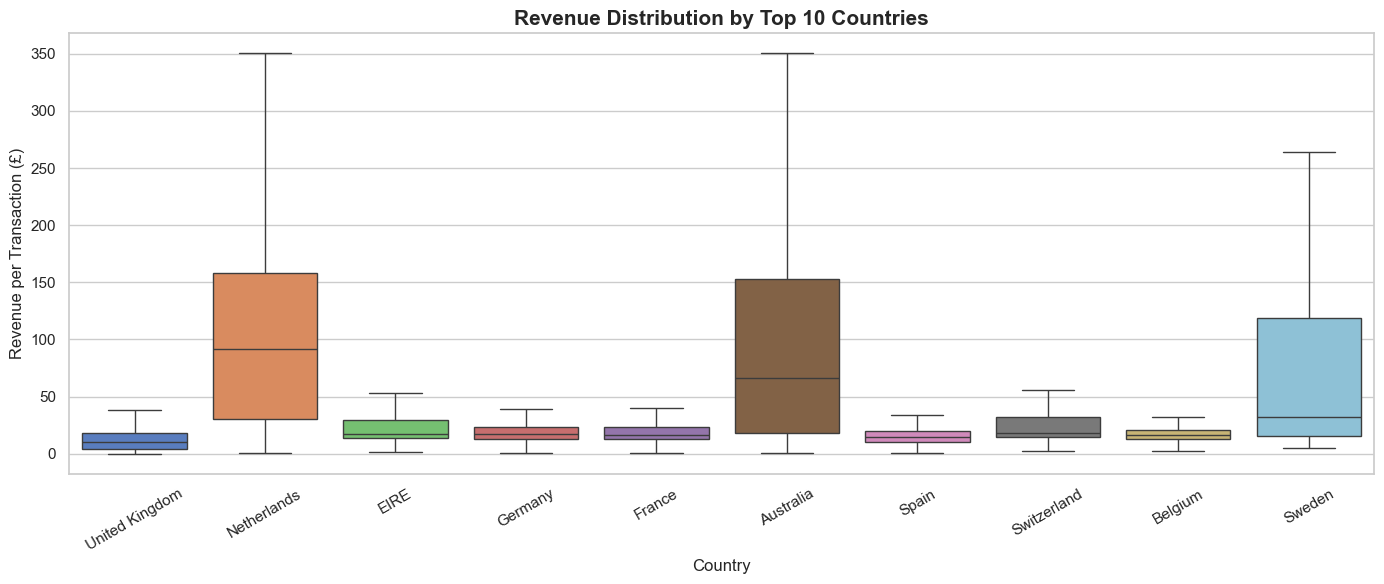

In [70]:
top_countries = country_revenue.head(10).index.tolist()
df_top = df[df['Country'].isin(top_countries)]

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(data=df_top, x='Country', y='Revenue',
            order=top_countries, palette='muted', ax=ax,
            showfliers=False)

ax.set_title('Revenue Distribution by Top 10 Countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue per Transaction (£)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/revenue_by_country_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6.a — Interpretation
While the United Kingdom dominates total revenue at £7,285,024, its median transaction value is the lowest among all top 10 countries by sitting below £20 per transaction. This reflects the sheer volume of small, frequent domestic orders rather than high individual transaction values. In contrast, the Netherlands and Australia stand out with significantly higher median transaction values of approximately £90 and £65 respectively and wide interquartile ranges extending to £350, indicating that these markets place fewer but substantially larger orders. Sweden also shows a notably elevated median and wide spread. This pattern suggests that international customers, particularly from the Netherlands and Australia, behave as high-volume wholesale buyers placing large consolidated orders, while UK customers transact more frequently in smaller quantities. These differences have direct implications for pricing strategy and account management by market.

### 4.7 — Heatmap: Purchase Activity by Day & Hour

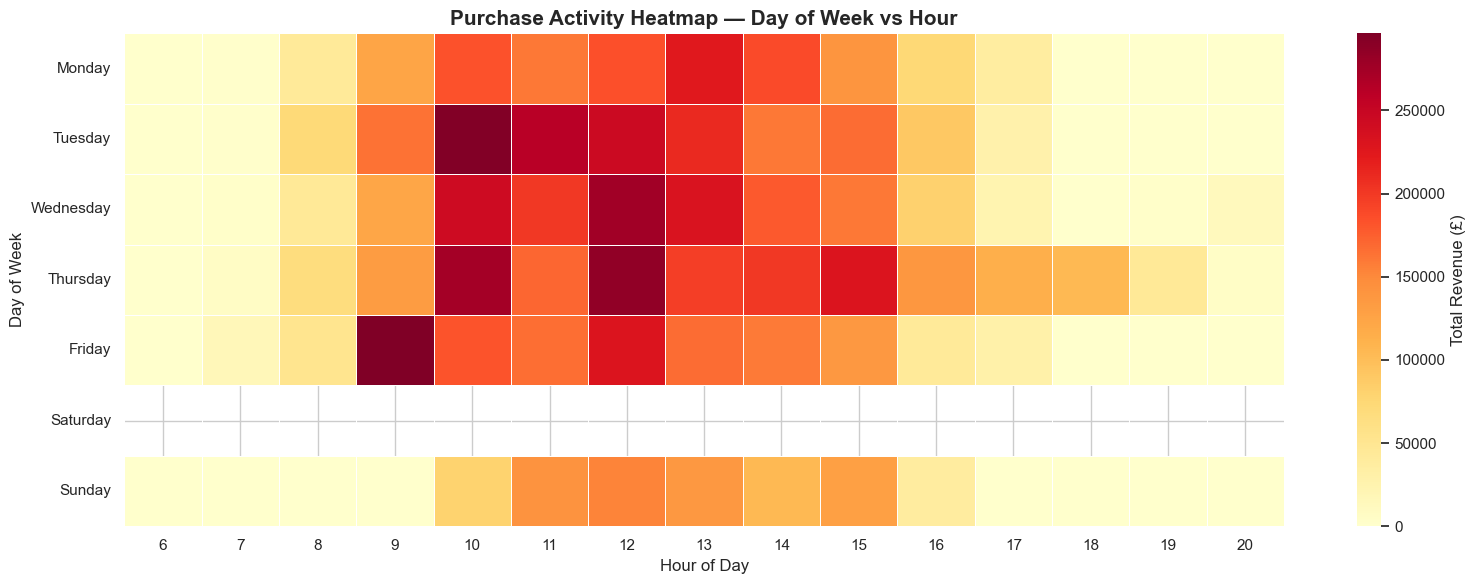

In [71]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['Revenue'].sum().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Total Revenue (£)'})

ax.set_title('Purchase Activity Heatmap — Day of Week vs Hour',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.7.a — Interpretation
Purchase activity is firmly concentrated within weekday business hours, with peak revenue generated between 09:00 and 15:00 from Tuesday to Thursday. The darkest cells, which are representing revenue above £250,000, cluster around 09:00–13:00 on Tuesday, Wednesday, and Thursday, identifying these as the highest-value purchasing windows in the week. Friday shows an unusual early peak at 09:00, suggesting customers front-load their orders before the weekend. Saturday shows near-zero activity across all hours, and Sunday, while showing some mid-day activity between 10:00 and 15:00, remains significantly below weekday levels. Thursday stands out as the only day with meaningful evening activity extending to 19:00–20:00. This weekday concentration strongly confirms a B2B wholesale customer base operating on standard business schedules, with Tuesday to Thursday mornings representing the optimal window for time-sensitive promotions and outreach campaigns.

---
## Section 5 — Advanced Analysis & Insights

### 5.1 — Customer Segmentation

Low/Mid boundary (33rd percentile): £384.10
Mid/High boundary (67th percentile): £1,212.80

Segment counts:
Revenue
Mid     1474
High    1432
Low     1432
Name: count, dtype: int64


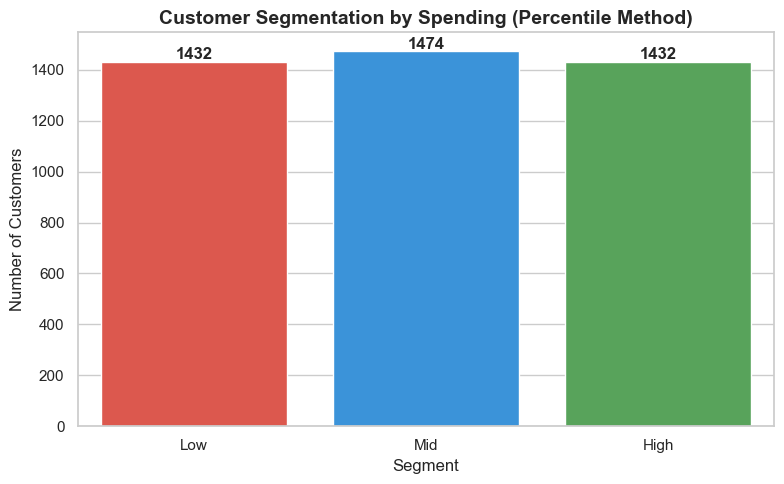

In [72]:
# Segmenting customers into High, Mid, and Low spenders
# using percentile-based thresholds (33rd and 67th percentile).
# Standard deviation segmentation was evaluated but rejected —
# the extreme right skew in this dataset produces a negative lower bound,
# making percentile thresholds the more appropriate method.

customer_spend = df.groupby('CustomerID')['Revenue'].sum()

low_threshold = customer_spend.quantile(0.33)
high_threshold = customer_spend.quantile(0.67)

def segment_percentile(spend):
    if spend >= high_threshold:
        return 'High'
    elif spend >= low_threshold:
        return 'Mid'
    else:
        return 'Low'

segments = customer_spend.apply(segment_percentile).value_counts()

print(f'Low/Mid boundary (33rd percentile): £{low_threshold:,.2f}')
print(f'Mid/High boundary (67th percentile): £{high_threshold:,.2f}')
print(f'\nSegment counts:')
print(segments)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#F44336', '#2196F3', '#4CAF50']
sns.barplot(x=segments.index, y=segments.values,
            order=['Low', 'Mid', 'High'],
            palette=colors, ax=ax)
ax.set_title('Customer Segmentation by Spending (Percentile Method)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')

for i, v in enumerate(segments.reindex(['Low', 'Mid', 'High']).values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()


#### 5.1.a — Interpretation
Percentile-based segmentation divides the 4,338 customers into three balanced groups. Low spenders (below £384) account for 1,432 customers, Mid spenders (£384–£1,213) account for 1,474, and High spenders (above £1,213) account for 1,432. The near-equal distribution across segments confirms that percentile thresholds are the appropriate method for this dataset. Standard deviation segmentation was evaluated but rejected because the extreme right skew produced a negative lower bound of £-6,937, which is statistically meaningless for spending data. The High segment, representing 33% of customers, generates a disproportionate share of total revenue and warrants priority retention investment.

### 5.2 — Repeat vs New Customer Analysis

Repeat customers (2+ orders): 2,845
One-time customers: 1,493
Repeat purchase probability: 65.6%


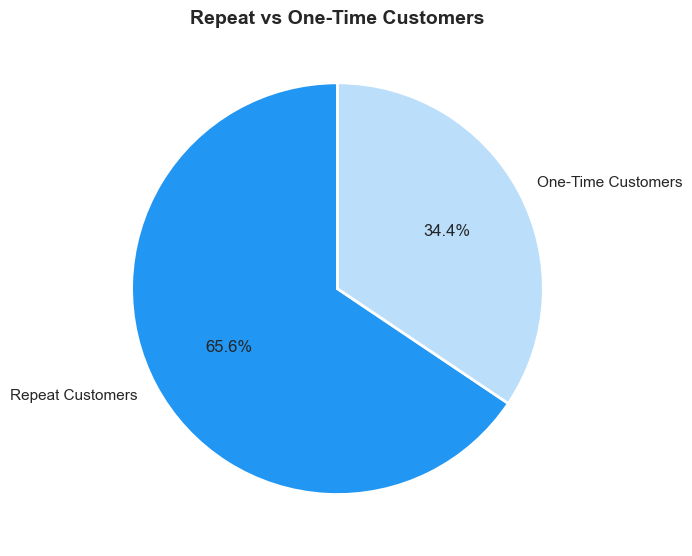

In [73]:
order_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (order_counts > 1).sum()
one_time_customers = (order_counts == 1).sum()
repeat_rate = (order_counts > 1).mean() * 100

print(f'Repeat customers (2+ orders): {repeat_customers:,}')
print(f'One-time customers: {one_time_customers:,}')
print(f'Repeat purchase probability: {repeat_rate:.1f}%')

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([repeat_customers, one_time_customers],
       labels=['Repeat Customers', 'One-Time Customers'],
       autopct='%1.1f%%',
       colors=['#2196F3', '#BBDEFB'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Repeat vs One-Time Customers', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/repeat_vs_new_customers.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.2.a — Interpretation
65.6% of customers placed more than one order, with 2,845 repeat buyers against 1,493 one-time customers. A repeat purchase rate above 65% reflects strong customer loyalty for a wholesale retailer where long-term account relationships drive sustained revenue. The average customer placed 4.27 orders, with the most active customer placing 209 orders which confirms that a core group of highly engaged buyers anchors the business. The 1,493 one-time customers represent an untapped retention opportunity, converting even 20% of them to repeat buyers would add approximately 299 additional loyal accounts.


### 5.3 — RFM Analysis (Recency, Frequency, Monetary)

In [74]:
# RFM scoring assigns each customer a score across three dimensions:
# Recency — how recently they purchased (lower days = better = higher score)
# Frequency — how many unique orders they placed
# Monetary — total revenue generated
# Each dimension scored 1–4 using quartiles.

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

print('=== RFM SUMMARY ===')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
print(f'\nTop 10 Customers by RFM Total Score:')
print(rfm.sort_values('RFM_Total', ascending=False)[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Total']].head(10).to_string(index=False))


=== RFM SUMMARY ===
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02

Top 10 Customers by RFM Total Score:
CustomerID  Recency  Frequency  Monetary  RFM_Total
     18283        4         16   2045.53         12
     18245        7          7   2567.06         12
     18241       10         17   2073.09         12
     18230        9          7   2810.20         12
     18229       12         20   7276.90         12
     18225        3         12   5504.96         12
     18223        5         14   6484.54         12
     18219        3         10   2069.77         12
     18210        2          6   2621.38         12
     18198        4         17   5425.56         12


#### 5.3.a — Interpretation
RFM scoring provides a multidimensional view of customer value that total revenue alone cannot capture. A customer who spent heavily a year ago but has not returned is less valuable than one who spent moderately last week. The top-scoring customers by RFM total are those who purchased recently, frequently, and at high monetary value. These represent the retailer's most engaged and commercially critical accounts. Customers with high Monetary but low Recency scores are lapsed high-value customers and represent the highest-priority re-engagement target, as they have demonstrated willingness to spend but have not returned.

### 5.4 — Country Revenue Ranking & Share Analysis

       Country  TotalRevenue  Transactions  Customers  RevenueShare%
United Kingdom   7285024.644         16646       3920          81.97
   Netherlands    285446.340            94          9           3.21
          EIRE    265262.460           260          3           2.98
       Germany    228678.400           457         94           2.57
        France    208934.310           389         87           2.35
     Australia    138453.810            57          9           1.56
         Spain     61558.560            90         30           0.69
   Switzerland     56443.950            51         21           0.64
       Belgium     41196.340            98         25           0.46
        Sweden     38367.830            36          8           0.43


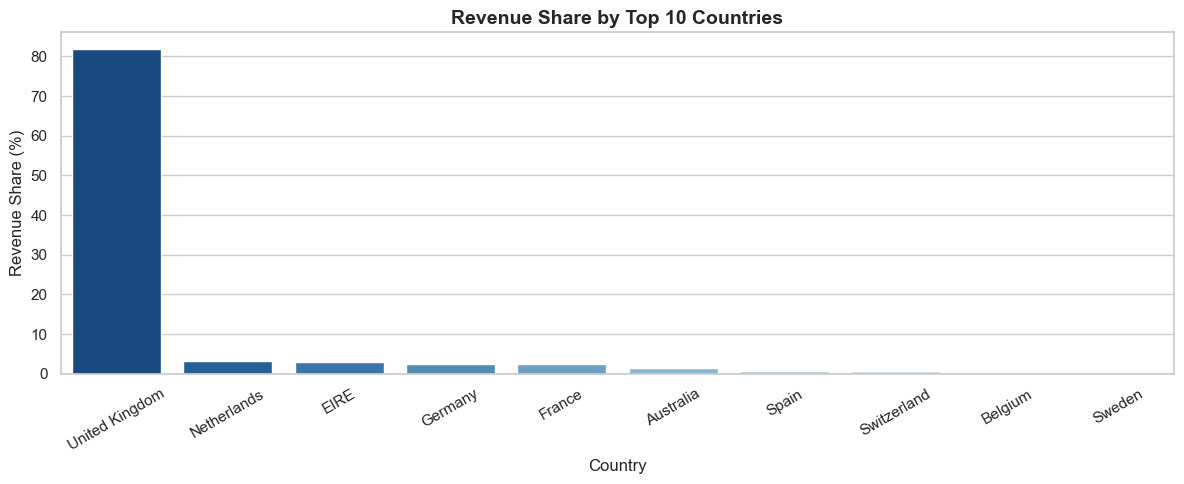

In [75]:
country_summary = df.groupby('Country').agg(
    TotalRevenue = ('Revenue', 'sum'),
    Transactions = ('InvoiceNo', 'nunique'),
    Customers    = ('CustomerID', 'nunique')
).reset_index()

country_summary['RevenueShare%'] = (country_summary['TotalRevenue'] /
                                     country_summary['TotalRevenue'].sum() * 100).round(2)
country_summary = country_summary.sort_values('TotalRevenue', ascending=False)

print(country_summary.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
top10 = country_summary.head(10)
sns.barplot(data=top10, x='Country', y='RevenueShare%', palette='Blues_r', ax=ax)
ax.set_title('Revenue Share by Top 10 Countries', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue Share (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/country_revenue_share.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.4.a — Interpretation
The United Kingdom accounts for 81.97% of total revenue, confirming extreme market concentration in the retailer's domestic market. The Netherlands (3.21%), Ireland (2.98%), and Germany (2.57%) are the next strongest markets but each hold less than 4% revenue share individually. The remaining six countries in the top 10  (France, Australia, Spain, Switzerland, Belgium, and Sweden) collectively account for less than 7% of total revenue. This level of geographic concentration presents a structural business risk, as any disruption to UK operations would have an immediate and severe impact on overall revenue performance.

### 5.5 — Peak Purchasing Period Identification

Revenue by Day of Week:
DayOfWeek
Monday            £1,363,604
Tuesday           £1,697,734
Wednesday         £1,584,284
Thursday          £1,973,016
Friday            £1,483,081
Saturday     No transactions
Sunday              £785,490
Name: Revenue, dtype: object

Top 5 Peak Hours:
Hour
12    £1,373,695
10    £1,259,268
13    £1,168,724
11    £1,101,178
14      £991,993
Name: Revenue, dtype: object


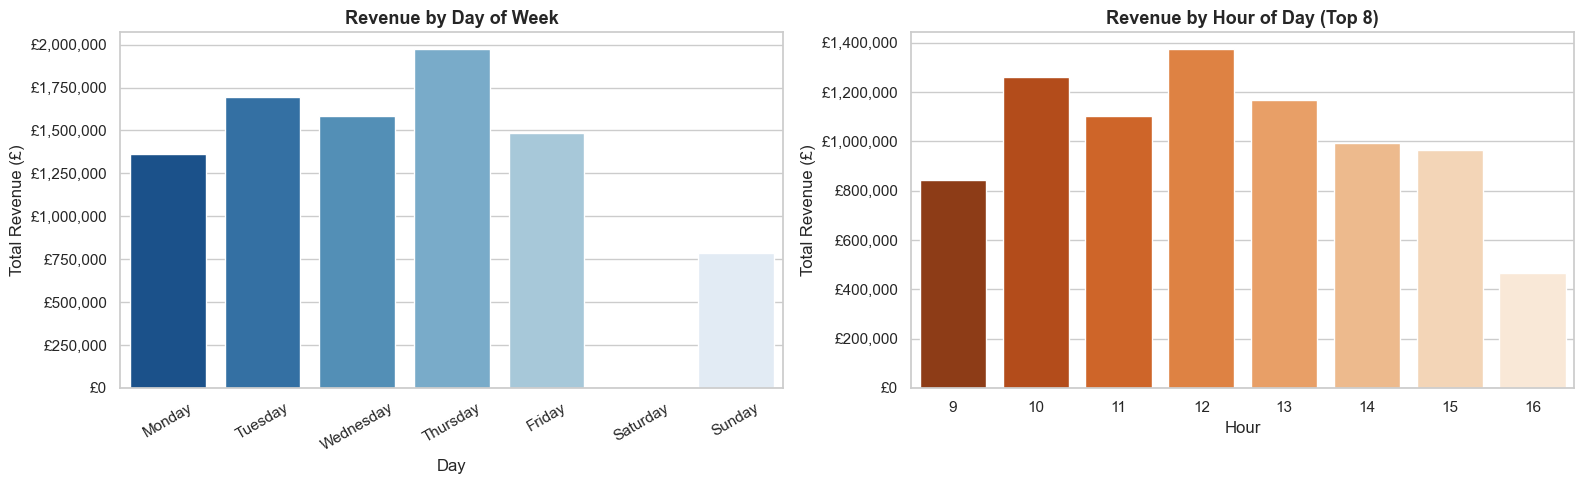

In [76]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

peak_day = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)
peak_hour = df.groupby('Hour')['Revenue'].sum().sort_values(ascending=False)

print('Revenue by Day of Week:')
print(peak_day.apply(lambda x: f'£{x:,.0f}' if pd.notna(x) else 'No transactions'))
print(f'\nTop 5 Peak Hours:')
print(peak_hour.head(5).apply(lambda x: f'£{x:,.0f}'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

peak_day_clean = peak_day.fillna(0)
sns.barplot(x=peak_day_clean.index, y=peak_day_clean.values,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=peak_hour.head(8).index, y=peak_hour.head(8).values,
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Revenue by Hour of Day (Top 8)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/peak_purchasing_periods.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.5.a — Interpretation
Thursday is the highest-revenue day at £1,973,016, followed by Tuesday at £1,697,734 and Wednesday at £1,584,284. Saturday recorded zero transactions, confirmed by a NaN value in the aggregation and Sunday generated only £785,490, the lowest of any active day. This sharp weekday concentration is definitive evidence of a B2B wholesale customer base operating on standard business schedules. The peak purchasing hour is 12:00 at £1,373,695, with strong activity sustained from 10:00 through 14:00. Thursday midday therefore represents the single highest-value purchasing window in the week and the optimal moment for time-sensitive promotions and outreach.


### 5.6 — Correlation: Purchase Frequency vs Total Spend

Correlation coefficient: 0.5528


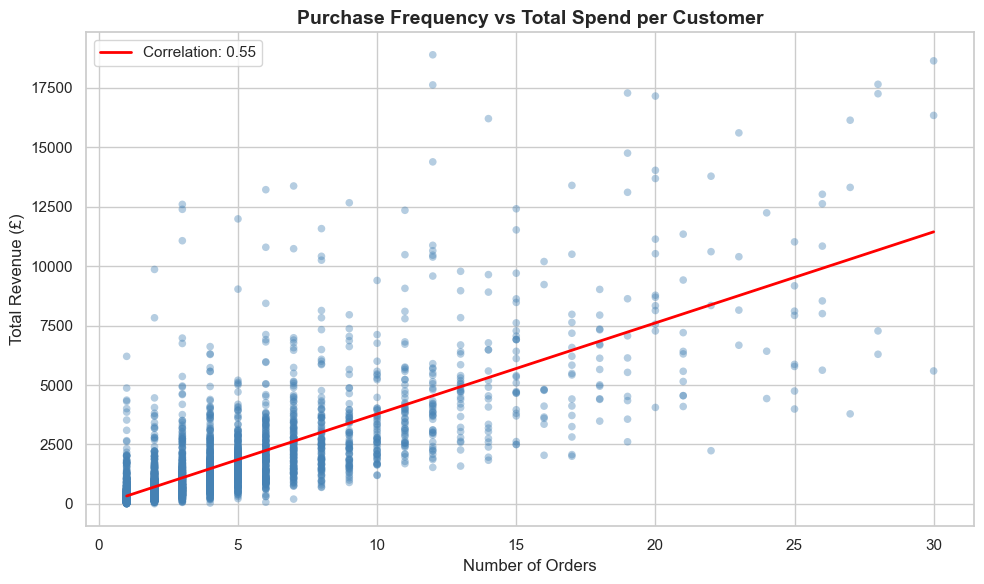

In [77]:
corr_data = df.groupby('CustomerID').agg(
    Frequency  = ('InvoiceNo', 'nunique'),
    TotalSpend = ('Revenue', 'sum')
).reset_index()

correlation = corr_data['Frequency'].corr(corr_data['TotalSpend'])
print(f'Correlation coefficient: {correlation:.4f}')

cap_freq = corr_data['Frequency'].quantile(0.99)
cap_spend = corr_data['TotalSpend'].quantile(0.99)
corr_capped = corr_data[(corr_data['Frequency'] <= cap_freq) &
                         (corr_data['TotalSpend'] <= cap_spend)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_capped['Frequency'], corr_capped['TotalSpend'],
           alpha=0.4, color='steelblue', edgecolors='none', s=30)

m, b = np.polyfit(corr_capped['Frequency'], corr_capped['TotalSpend'], 1)
x_line = np.linspace(corr_capped['Frequency'].min(), corr_capped['Frequency'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Correlation: {correlation:.2f}')

ax.set_title('Purchase Frequency vs Total Spend per Customer',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Total Revenue (£)')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/mac/Desktop/DSA1080/Final Project/visuals/frequency_vs_spend_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


#### 5.6.a — Interpretation
Purchase frequency and total spend show a moderate positive correlation of 0.55. This confirms a meaningful relationship; customers who order more frequently tend to spend more in total but the correlation is not perfect, indicating that order size also plays a significant independent role in determining customer value. A customer placing fewer large orders can outspend a high-frequency buyer placing small ones. This finding suggests that loyalty programs should reward both frequency and order value rather than frequency alone, to capture the full spectrum of high-value customer behavior.

### 5.7 — Key Insights

**Insight 1 — Revenue is critically concentrated in a single market**

The United Kingdom accounts for 81.97% of total revenue. The next nine markets combined contribute less than 18%. This level of geographic concentration creates structural business risk. Any disruption to UK operations would have an immediate and severe impact on overall performance.

**Insight 2 — A small high-value customer segment anchors total revenue**

Percentile-based segmentation reveals that the top 33% of customers (those spending above £1,213) generate a disproportionate share of total revenue. The most active customer placed 209 orders and the highest spender generated £280,206. Retaining this segment is the single highest commercial priority.

**Insight 3 — Repeat purchase rate of 65.6% confirms strong customer loyalty**

2,845 of 4,338 customers returned for a second order, with an average of 4.27 orders per customer. This retention rate is strong for a wholesale retailer. However, 1,493 one-time customers represent an untapped opportunity; converting 20% of them to repeat buyers would add approximately 299 loyal accounts.

**Insight 4 — Q4 seasonal concentration creates revenue fragility**

November is the single highest revenue month at £1,156,205 (more than double February's £446,085). Over 40% of annual revenue is generated between September and November. Any Q4 disruption to supply chain, logistics, or demand would collapse annual targets.

**Insight 5 — International markets are underleveraged relative to their order value**

The Netherlands and Australia place far fewer orders than the UK but at significantly higher median transaction values. Approximately £90 and £65 per transaction respectively versus under £20 for the UK. These markets demonstrate high-value wholesale buying behavior and represent the strongest candidates for targeted international expansion.


### 5.8 — Recommendations

**Recommendation 1 — Launch a high-value customer retention program**

Identify customers in the top RFM quartile and assign dedicated account management. Offer volume-based pricing incentives, early access to new products, and quarterly business reviews. Given that the top spending segment drives a disproportionate share of revenue, losing even a handful of these accounts would have material financial impact.

**Recommendation 2 — Invest in international market development for the Netherlands and Australia**

Both markets demonstrate high median transaction values and wholesale buying patterns consistent with the retailer's core business model. A targeted expansion strategy, including localized account managers, country-specific promotions, and logistics partnerships, could significantly grow revenue from these markets without requiring proportional increases in transaction volume.

**Recommendation 3 — Implement an H1 revenue activation campaign to reduce Q4 dependency**

February and April are the two weakest months at £446,085 and £468,374 respectively. A structured H1 promotional calendar, including early-year loyalty discounts, new product launches in January and February, and spring campaign bundles, would reduce seasonal revenue concentration, improve cash flow stability, and reduce the business risk created by over-reliance on Q4 performance.

In [80]:
import os
visuals = sorted(os.listdir('/Users/mac/Desktop/DSA1080/Final Project/visuals'))
print(f'Total visuals saved: {len(visuals)}')
for v in visuals:
    print(f'  - {v}')

Total visuals saved: 13
  - .DS_Store
  - README.md
  - activity_heatmap.png
  - country_revenue_share.png
  - customer_segmentation.png
  - customer_spending_distribution.png
  - frequency_vs_spend_correlation.png
  - monthly_revenue_trend.png
  - notebook.ipynb
  - peak_purchasing_periods.png
  - repeat_vs_new_customers.png
  - revenue_by_country_boxplot.png
  - top10_products_revenue.png
